8. In this exercise, we will generate simulated data, and will then use this data to perform forward and backward stepwise selection.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

np.random.seed(1)

n = 100
X = np.random.randn(n)
eps = np.random.randn(n)

(a)

Create a random number generator and use its normal() method to generate a predictor X of length n = 100, as well as a noise vector ϵ of length n = 100.

In [3]:
# (a) 生成 X, eps
X = X.reshape(-1, 1)

(b)

Generate a response vector Y of length n = 100 according to the model

Y = β0 + β1 * X + β2 * X2 + β3 * X3 + eps

where beta0, beta1, beta2, and beta3 are constants of your choice.

In [4]:
# (b) Y = β0 + β1 * X + β2 * X2 + β3 * X3 + eps
beta0, beta1, beta2, beta3 = 1, 2, 3, 4
Y = beta0 + beta1*X[:,0] + beta2*X[:,0]**2 + beta3*X[:,0]**3 + eps

# 建立 DataFrame，含 X^1 ~ X^10
df = pd.DataFrame({"Y": Y, "X1": X[:,0]})
for k in range(2, 11):
    df[f"X{k}"] = df["X1"] ** k


# ================
# Helper: 計算 Cp
# ================
def calc_cp(y, y_pred, p, sigma2):
    RSS = np.sum((y - y_pred)**2)
    return RSS/n + 2 * p * sigma2 / n

(c) Use forward stepwise selection in order to select a model containing the predictors X, X2, . . . , X10. What is the model obtained according to Cp? Report the coefficients of the model obtained.

In [5]:
# (c) Forward Stepwise Selection
predictors = [f"X{k}" for k in range(1, 11)]
selected = []
remaining = predictors.copy()

sigma2 = np.var(eps)   # 真實 noise variance（理論 Cp 需此值）
models_forward = []

for k in range(1, 11):        # 最多選 10 個
    best_cp = np.inf
    best_var = None
    best_model = None

    for var in remaining:
        vars_try = selected + [var]
        Xmat = sm.add_constant(df[vars_try])
        model = sm.OLS(df["Y"], Xmat).fit()
        cp_val = calc_cp(df["Y"], model.predict(Xmat), len(vars_try), sigma2)

        if cp_val < best_cp:
            best_cp = cp_val
            best_var = var
            best_model = model

    selected.append(best_var)
    remaining.remove(best_var)
    models_forward.append((selected.copy(), best_model, best_cp))

print("=== Forward Stepwise Selection (Cp chosen model) ===")
best_fwd = min(models_forward, key=lambda x: x[2])
print("Selected variables:", best_fwd[0])
print(best_fwd[1].summary())


=== Forward Stepwise Selection (Cp chosen model) ===
Selected variables: ['X3', 'X2', 'X1', 'X6']
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     4574.
Date:                Sun, 23 Nov 2025   Prob (F-statistic):          1.14e-107
Time:                        15:31:53   Log-Likelihood:                -130.61
No. Observations:                 100   AIC:                             271.2
Df Residuals:                      95   BIC:                             284.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

(d) Repeat (c), using backwards stepwise selection. How does your answer compare to the results in (c)?

In [7]:
# (d) Backward Stepwise Selection
remaining = predictors.copy()
models_backward = []

for k in range(10, 0, -1):
    best_cp = np.inf
    best_vars = None
    best_model = None

    for var in remaining:
        vars_try = [v for v in remaining if v != var]
        Xmat = sm.add_constant(df[vars_try])
        model = sm.OLS(df["Y"], Xmat).fit()
        cp_val = calc_cp(df["Y"], model.predict(Xmat), len(vars_try), sigma2)

        if cp_val < best_cp:
            best_cp = cp_val
            best_vars = vars_try
            best_model = model

    remaining = best_vars
    models_backward.append((remaining.copy(), best_model, best_cp))

print("\n=== Backward Stepwise Selection (Cp chosen model) ===")
best_bwd = min(models_backward, key=lambda x: x[2])
print("Selected variables:", best_bwd[0])
print(best_bwd[1].summary())


=== Backward Stepwise Selection (Cp chosen model) ===
Selected variables: ['X1', 'X2', 'X3', 'X6']
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     4574.
Date:                Sun, 23 Nov 2025   Prob (F-statistic):          1.14e-107
Time:                        15:32:34   Log-Likelihood:                -130.61
No. Observations:                 100   AIC:                             271.2
Df Residuals:                      95   BIC:                             284.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

(e) Now fit a lasso model to the simulated data, again using X, X2
, . . . , X10 as predictors. Use cross-validation to select the optimal value of λ. Create plots of the cross-validation error as a function of λ. Report the resulting coefficient estimates, and discuss the results obtained.


=== Lasso CV Result ===
Best λ: 0.027389895065218047
Coefficients:
X1: 1.6846
X2: 2.7709
X3: 10.4161
X4: 0.5496
X5: 0.0000
X6: 0.0584
X7: 0.0000
X8: 0.0000
X9: 0.0000
X10: 0.0000


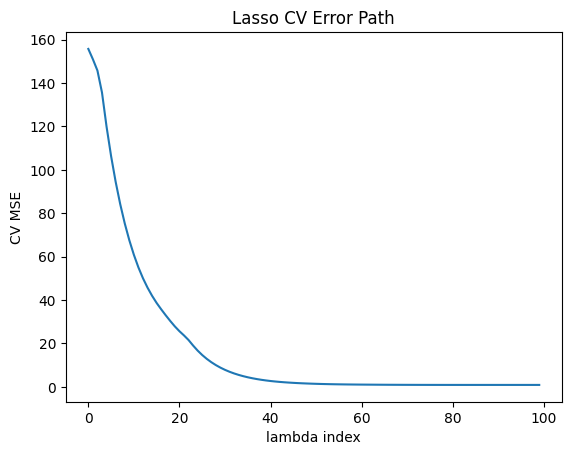

In [9]:
# (e) Lasso + Cross-Validation
from sklearn.preprocessing import StandardScaler

X_lasso = df[predictors].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_lasso)

lasso_cv = LassoCV(cv=10).fit(X_scaled, Y)
coef_lasso = lasso_cv.coef_

print("\n=== Lasso CV Result ===")
print("Best λ:", lasso_cv.alpha_)
print("Coefficients:")
for name, coef in zip(predictors, coef_lasso):
    print(f"{name}: {coef:.4f}")

# Plot CV error
plt.plot(lasso_cv.mse_path_.mean(axis=1))
plt.xlabel("lambda index")
plt.ylabel("CV MSE")
plt.title("Lasso CV Error Path")
plt.show()

(f) Now generate a response vector Y according to the model

Y = β0 + β7 * X7 + eps

and perform forward stepwise selection and the lasso. Discuss the results obtained.

In [11]:
# (f) New model:  Y = β0 + β7 * X7 + eps
beta7 = 10
Y2 = beta0 + beta7 * X[:,0]**7 + eps
df["Y2"] = Y2

# forward selection again
selected = []
remaining = predictors.copy()
models_forward2 = []

for k in range(1,11):
    best_cp = np.inf
    for var in remaining:
        vars_try = selected + [var]
        Xmat = sm.add_constant(df[vars_try])
        model = sm.OLS(df["Y2"], Xmat).fit()
        cp_val = calc_cp(df["Y2"], model.predict(Xmat), len(vars_try), sigma2)
        if cp_val < best_cp:
            best_cp = cp_val
            best_var = var
            best_model = model
    selected.append(best_var)
    remaining.remove(best_var)
    models_forward2.append((selected.copy(), best_model, best_cp))

print("\n=== Forward Stepwise (Y = β0 + β7 X^7 + eps) ===")
best_fwd2 = min(models_forward2, key=lambda x: x[2])
print("Selected variables:", best_fwd2[0])
print(best_fwd2[1].summary())

# lasso
lasso_cv2 = LassoCV(cv=10).fit(X_scaled, Y2)
print("\n=== Lasso for new model ===")
print("Best λ:", lasso_cv2.alpha_)
for name, coef in zip(predictors, lasso_cv2.coef_):
    print(f"{name}: {coef:.4f}")


=== Forward Stepwise (Y = β0 + β7 X^7 + eps) ===
Selected variables: ['X7', 'X10', 'X2']
                            OLS Regression Results                            
Dep. Variable:                     Y2   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.019e+07
Date:                Sun, 23 Nov 2025   Prob (F-statistic):          5.76e-264
Time:                        15:34:26   Log-Likelihood:                -131.26
No. Observations:                 100   AIC:                             270.5
Df Residuals:                      96   BIC:                             280.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------